Calculating and cluster per capita, that is including the population in context

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ML Model
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
# import joined dataframe
df = pd.read_csv('data/processed/Cleaned_Data.csv')

print(f'Data loaded. Shape: {df.shape}')
df.head(2)

Data loaded. Shape: (104, 26)


,Neighbourhood,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Manslaughter,Murder 1st Dgree,Murder 2nd Dgree,Shootings,Other,Population,Police_Critical,Police_High,Police_Medium,geometry
0,Barrhaven,3,208,0,79,258,10,171,0,59,346,9,3,4,103.0,61.0,0.0,3.0,0.0,2.0,563.0,39166,185,2592,5100,"POLYGON ((-75.7742283499069 45.2610220238087, ..."
1,Bayshore,3,278,1,129,244,6,203,11,73,1722,42,0,5,119.0,90.0,0.0,0.0,0.0,8.0,667.0,9313,80,1089,2501,"POLYGON ((-75.802358463964 45.3572739626829, -..."


calculate per capita = crime/population * 100

In [10]:
df_capita = df.copy()
per_capita = ['Arson', 'Assaults',
       'Attempting The Commission Of A Capital Crime', 'Break and Enter',
       'Mischief', 'Offensive Weapons',
       'Other Violations Involving Violence Or The Threat Of Violence',
       'Possession / Trafficking Stolen Goods', 'Sexual Violations',
       'Theft $5000 and Under', 'Theft Over $5000', 'Violations Causing Death',
       'Violations Resulting In The Deprivation Of Freedom', 'Auto Theft',
       'Bike Theft', 'Manslaughter', 'Murder 1st Dgree', 'Murder 2nd Dgree',
       'Shootings', 'Other']

for i in per_capita:
    df_capita[i] = (df_capita[i]/df_capita['Population']) * 1000

# drop these columns
drop_cols = ['Population','Police_Critical','Police_High','Police_Medium']
df_capita.drop(columns=drop_cols, inplace=True)

df_capita.head(2)

,Neighbourhood,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Manslaughter,Murder 1st Dgree,Murder 2nd Dgree,Shootings,Other,geometry
0,Barrhaven,0.076597,5.310729,0.000000,2.017056,6.587346,0.255323,4.366032,0.000000,1.506409,8.834193,0.229791,0.076597,0.102129,2.629832,1.557473,0.0,0.076597,0.0,0.051065,14.374713,"POLYGON ((-75.7742283499069 45.2610220238087, ..."
1,Bayshore,0.322130,29.850746,0.107377,13.851605,26.199936,0.644261,21.797487,1.181145,7.838505,184.902824,4.509825,0.000000,0.536884,12.777837,9.663911,0.0,0.000000,0.0,0.859014,71.620316,"POLYGON ((-75.802358463964 45.3572739626829, -..."


Machine Learing

1. Elbow Method

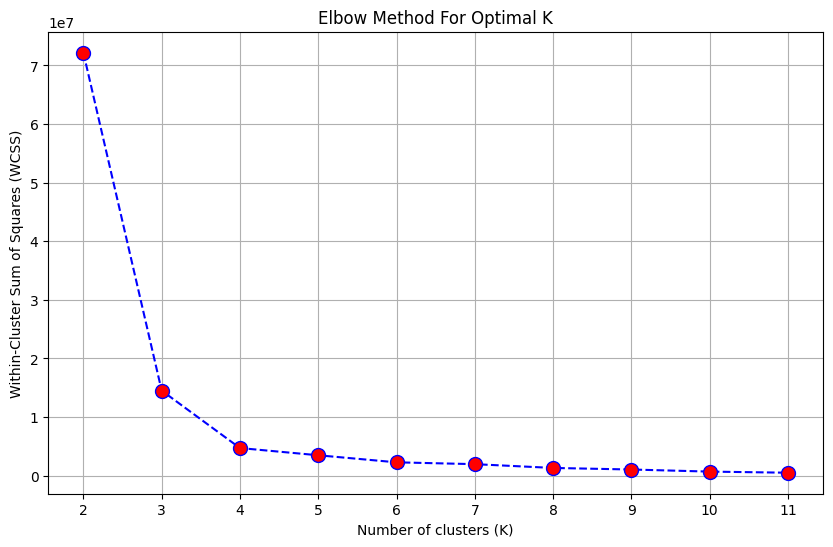

In [11]:
k = range(2, 12)
K = []
WCSS = []
for i in k:
    kmodel = KMeans(n_clusters=i, random_state=42).fit(df_capita.drop(columns=['Neighbourhood','geometry']))
    wcss_score = kmodel.inertia_
    WCSS.append(wcss_score)
    K.append(i)

# store the number of clusters and their corresponding WCSS scores in a DataFrame
elbow_df = pd.DataFrame({'K': K, 'WCSS': WCSS})

# plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(elbow_df['K'], elbow_df['WCSS'], marker='o', color = 'blue', linestyle = '--', markerfacecolor = 'red', markersize = 10)
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K)
plt.grid()
plt.show()

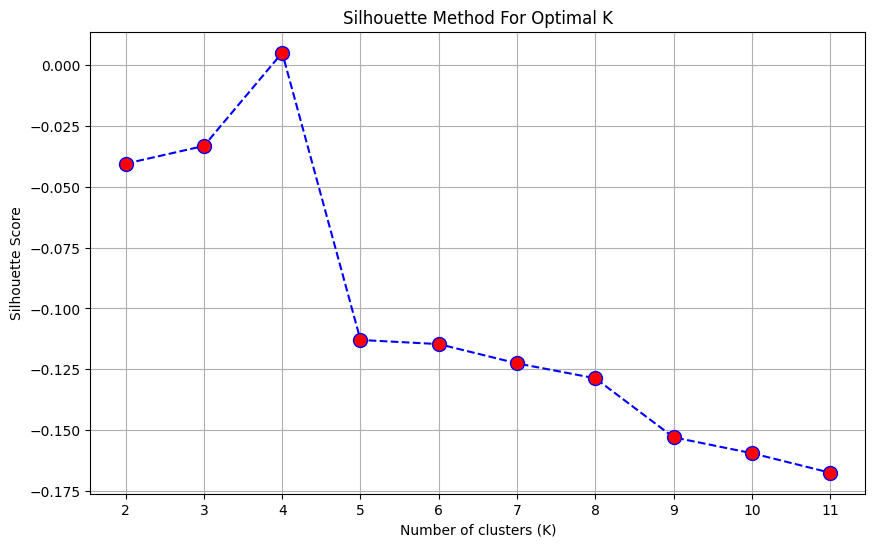

In [12]:
# calculate silhouette scores for k=2-10
k = range(2, 12)
K = []
ss = []
for i in k:
    kmodel = KMeans(n_clusters=i, random_state=42).fit(df_capita.drop(columns=['Neighbourhood','geometry']))
    labels = kmodel.labels_
    sil_score = silhouette_score(df.drop(columns=['Neighbourhood','geometry']), labels)
    ss.append(sil_score)
    K.append(i) 

# store the number of clusters and their corresponding silhouette scores in a DataFrame
elbow_df['Silhouette Score'] = ss

# plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(elbow_df['K'], elbow_df['Silhouette Score'], marker='o', color = 'blue', linestyle = '--', markerfacecolor = 'red', markersize = 10)
plt.title('Silhouette Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K)
plt.grid()
plt.show()

In [24]:
x = df_capita.drop(columns=['Neighbourhood','geometry'])

# scale
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

model = KMeans(n_clusters = 8,
                init = 'k-means++',
                max_iter = 100,
                n_init = 'auto',
                random_state = 42)

# ASSIGN CLUSTERS - fit and predict
df_capita['cluster'] = model.fit_predict(x_scaled)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


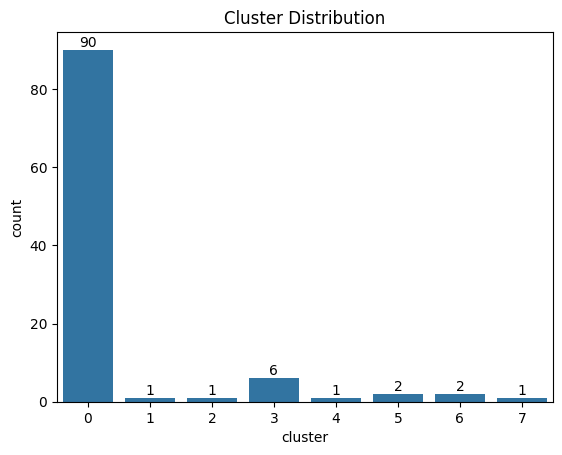

In [25]:
ax = sns.countplot(x="cluster", data=df_capita)
plt.title("Cluster Distribution")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height(),
            str(int(p.get_height())), ha="center", va="bottom")

plt.show()

In [27]:
df_capita[df_capita['cluster'] == 3]

,Neighbourhood,Arson,Assaults,Attempting The Commission Of A Capital Crime,Break and Enter,Mischief,Offensive Weapons,Other Violations Involving Violence Or The Threat Of Violence,Possession / Trafficking Stolen Goods,Sexual Violations,Theft $5000 and Under,Theft Over $5000,Violations Causing Death,Violations Resulting In The Deprivation Of Freedom,Auto Theft,Bike Theft,Manslaughter,Murder 1st Dgree,Murder 2nd Dgree,Shootings,Other,geometry,cluster
13,Britannia Village,2.751032,62.051047,0.305670,37.138927,45.697692,3.668042,44.933517,1.528351,12.226807,151.765245,2.751032,0.305670,2.139691,15.436344,14.825004,0.152835,0.152835,0.000000,1.986856,103.775027,"POLYGON ((-75.7891756297096 45.3740270347074, ...",3
25,Cityview - Skyline - Fisher Heights,0.387057,19.352841,0.077411,13.469577,14.785571,0.541880,11.921350,0.309645,3.870568,139.572689,2.631986,0.232234,0.077411,8.437839,5.109150,0.154823,0.077411,0.000000,0.309645,47.298343,"POLYGON ((-75.7333072915247 45.3505600795003, ...",3
52,Katimavik - Hazeldean,0.338983,27.457627,0.000000,13.389831,26.440678,0.508475,19.915254,1.016949,8.644068,125.338983,2.542373,0.084746,0.762712,11.864407,7.372881,0.084746,0.000000,0.000000,0.084746,87.881356,"POLYGON ((-75.8962442180397 45.293132576744, -...",3
58,Lowertown,7.774210,334.629035,0.676018,137.400710,166.300490,31.941862,143.653879,14.703397,44.786209,1272.773365,12.675342,1.690046,5.239141,33.293899,101.064729,0.169005,0.845023,0.676018,3.549096,538.448538,MULTIPOLYGON (((-75.688860274441 45.4362427667...,3
97,Vanier North,3.010172,91.654557,0.622794,65.393398,62.175628,4.567158,44.425991,3.840565,13.182479,151.131410,6.020345,0.830392,2.698775,13.909072,32.696699,0.103799,0.207598,0.518995,1.868383,125.285447,"POLYGON ((-75.6492893396724 45.4454602271352, ...",3
100,West Centertown,3.956981,87.053571,0.507305,89.387175,82.487825,4.565747,48.295455,3.145292,14.204545,244.521104,9.943182,0.608766,1.623377,18.770292,68.486201,0.101461,0.101461,0.405844,1.217532,201.806006,"POLYGON ((-75.7074610197816 45.4143845166467, ...",3
